# Import Libraries 

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load Dataset

In [4]:
#read the csv and perform all the numpy and pandas functions
df = pd.read_csv("AI_Impact_on_Jobs_2030.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
df.isnull().sum()
df.duplicated().sum()





df:                  Job_Title  Average_Salary  Years_Experience Education_Level  \
0          Security Guard           45795                28        Master's   
1      Research Scientist          133355                20             PhD   
2     Construction Worker          146216                 2     High School   
3       Software Engineer          136530                13             PhD   
4       Financial Analyst           70397                22     High School   
...                   ...             ...               ...             ...   
2995               Doctor          111319                 6      Bachelor's   
2996        UX Researcher           44363                29             PhD   
2997       Data Scientist           61325                23        Master's   
2998     Graphic Designer          110296                 7             PhD   
2999     Graphic Designer          123909                25             PhD   

      AI_Exposure_Index  Tech_Growth_Factor  A

np.int64(0)

# Numpy Operations

In [8]:
automation_prob = np.array(df['Automation_Probability_2030'].dropna())

print("AI Jobs 2030 - Automation Probability Mean        : ", np.mean(automation_prob))
print("AI Jobs 2030 - Automation Probability Average     : ", np.average(automation_prob))
print("AI Jobs 2030 - Automation Probability Std         : ", np.std(automation_prob))
print("AI Jobs 2030 - Automation Probability Median      : ", np.median(automation_prob))
print("AI Jobs 2030 - Automation Probability Percentile 25: ", np.percentile(automation_prob, 25))
print("AI Jobs 2030 - Automation Probability Percentile 75: ", np.percentile(automation_prob, 75))
print("AI Jobs 2030 - Automation Probability Percentile 3 : ", np.percentile(automation_prob, 3))
print("AI Jobs 2030 - Automation Probability Min         : ", np.min(automation_prob))
print("AI Jobs 2030 - Automation Probability Max         : ", np.max(automation_prob))



AI Jobs 2030 - Automation Probability Mean        :  0.5015033333333333
AI Jobs 2030 - Automation Probability Average     :  0.5015033333333333
AI Jobs 2030 - Automation Probability Std         :  0.24783994833135536
AI Jobs 2030 - Automation Probability Median      :  0.5
AI Jobs 2030 - Automation Probability Percentile 25:  0.31
AI Jobs 2030 - Automation Probability Percentile 75:  0.7
AI Jobs 2030 - Automation Probability Percentile 3 :  0.08
AI Jobs 2030 - Automation Probability Min         :  0.05
AI Jobs 2030 - Automation Probability Max         :  0.95


# Seaborn Graphs

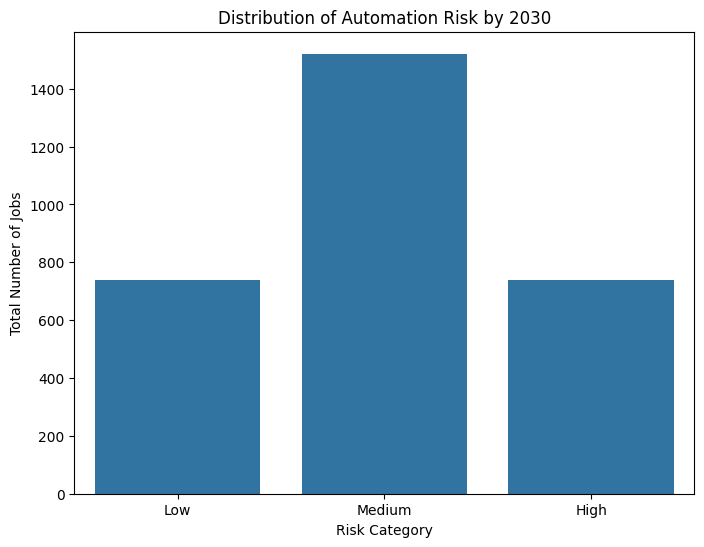

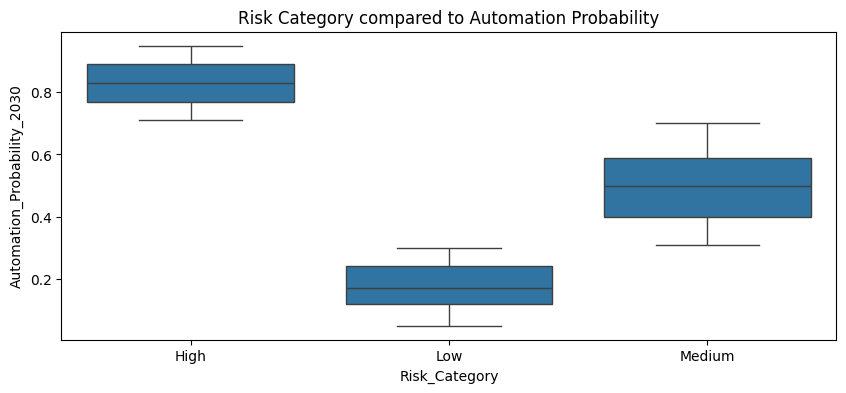

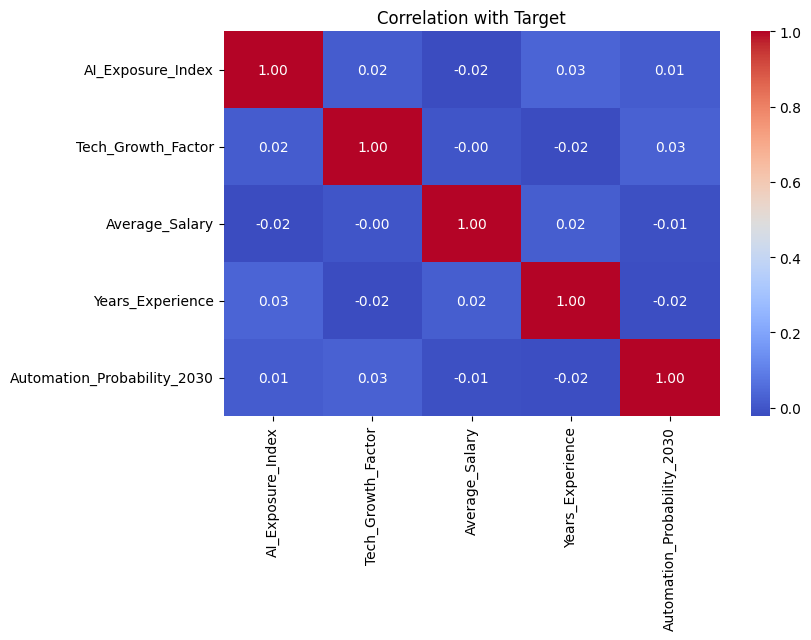

In [9]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Risk_Category", order=["Low", "Medium", "High"])

plt.title("Distribution of Automation Risk by 2030")
plt.xlabel("Risk Category")
plt.ylabel("Total Number of Jobs")

plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x="Risk_Category",y="Automation_Probability_2030",data=df)
plt.title("Risk Category compared to Automation Probability")
plt.show()

cols = ['AI_Exposure_Index','Tech_Growth_Factor',
        'Average_Salary','Years_Experience',
        'Automation_Probability_2030']


plt.figure(figsize=(8,5))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation with Target")
plt.show()


# Feature Selection 

In [ ]:
# Taken 4 Features ('AI_Exposure_Index', 'Tech_Growth_Factor', 'Average_Salary','Years_Experience')
y = df['Automation_Probability_2030']   
X = df[ ['AI_Exposure_Index', 'Tech_Growth_Factor', 'Average_Salary','Years_Experience' ]] #these are my x features 

SEED = 42
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,  
                                                    random_state=SEED)   #80% will be training data and 20% will be testing data 

print("X.shape:     \n", X.shape ) 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


X.shape:     
 (3000, 4)


# 3 Models Applied

In [ ]:

# LINEAR REGRESSION 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error


regressor = LinearRegression()
regressor.fit(X_train, y_train)

print("=" * 50)
print("LINEAR REGRESSION")
print("=" * 50)
print("Intercept:\n", regressor.intercept_)
print("Coefficients:", regressor.coef_)

feature_names = X.columns
coefficients_df = pd.DataFrame(data=regressor.coef_,
                                index=feature_names,
                                columns=['Coefficient value'])
print(coefficients_df)

y_pred_lr = regressor.predict(X_test)
results_lr = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr})
print("Actual vs Predicted:\n", results_lr)

mae  = mean_absolute_error(y_test, y_pred_lr)
mse  = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_lr)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')

# RIDGE REGRESSION
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("\n" + "=" * 50)
print("RIDGE REGRESSION")
print("=" * 50)
print("Intercept:\n", ridge.intercept_)

ridge_coef_df = pd.DataFrame(data=ridge.coef_,
                              index=feature_names,
                              columns=['Coefficient value'])
print(ridge_coef_df)

y_pred_ridge = ridge.predict(X_test)
results_ridge = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_ridge})
print("Actual vs Predicted:\n", results_ridge)

mae  = mean_absolute_error(y_test, y_pred_ridge)
mse  = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_ridge)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')

# LASSO REGRESSION
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train, y_train)

print("\n" + "=" * 50)
print("LASSO REGRESSION")
print("=" * 50)
print("Intercept:\n", lasso.intercept_)

lasso_coef_df = pd.DataFrame(data=lasso.coef_,
                              index=feature_names,
                              columns=['Coefficient value'])
print(lasso_coef_df)

y_pred_lasso = lasso.predict(X_test)
results_lasso = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lasso})
print("Actual vs Predicted:\n", results_lasso)

mae  = mean_absolute_error(y_test, y_pred_lasso)
mse  = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_lasso)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')


LINEAR REGRESSION
Intercept:
 0.5007583333333333
Coefficients: [ 0.00586317  0.00294579 -0.0039217  -0.00539442]
                    Coefficient value
AI_Exposure_Index            0.005863
Tech_Growth_Factor           0.002946
Average_Salary              -0.003922
Years_Experience            -0.005394
Actual vs Predicted:
       Actual  Predicted
1801    0.54   0.502939
1190    0.75   0.507487
1817    0.45   0.504472
251     0.42   0.498832
2505    0.34   0.505976
...      ...        ...
104     0.70   0.511608
2087    0.27   0.484009
599     0.38   0.506386
1756    0.60   0.513828
1323    0.82   0.487901

[600 rows x 2 columns]
MAE  : 0.22
MSE  : 0.06
RMSE : 0.25
R²   : -0.0008

RIDGE REGRESSION
Intercept:
 0.5007583333333333
                    Coefficient value
AI_Exposure_Index            0.005861
Tech_Growth_Factor           0.002945
Average_Salary              -0.003920
Years_Experience            -0.005392
Actual vs Predicted:
       Actual  Predicted
1801    0.54   0.502938
119

In [ ]:

# V1 — REGRESSION ANALYSIS (Automation Probability as Target)
# Features: AI_Exposure_Index, Tech_Growth_Factor,
#           Average_Salary, Years_Experience (4 pure numeric)
# Target: Automation_Probability_2030 (continuous)

# All three models produced identical poor results:
# Linear → R²: -0.0008, MAE: 0.22, RMSE: 0.25
# Ridge  → R²: -0.0008, MAE: 0.22, RMSE: 0.25
# Lasso  → R²: -0.0007, MAE: 0.22, RMSE: 0.25

# Negative R² means model performed worse than
# simply predicting the mean value every time
# All predictions clustered around 0.50 (mean)
# regardless of actual values ranging from 0.05 to 0.95

# Coefficients are extremely small (0.005, 0.002)
# confirming no feature has meaningful impact on target
# Correlation heatmap verified — all features have
# less than 0.03 correlation with Automation Probability

# Lasso reduced coefficients further but could not
# zero them out — all 4 features equally weak

# Conclusion: V1 used only 4 pure numeric features
# without any encoding — pipeline correctly implemented
# but weak feature selection led to negative R²

